# Task 1B Preprocessing  -  Instacart LSTM Demand Forecasting

Preprocesses the Instacart dataset to produce sliding-window time-series arrays for training a global LSTM demand forecasting model.

In [1]:
from pathlib import Path
from google.colab import drive

# Mount Google Drive so all project files are accessible at /content/drive.
drive.mount('/content/drive')

# Update this path to match the location of the project root on your Google Drive.
DRIVE_ROOT      = Path('/content/drive/MyDrive/Advanced AI/advanced-ai')
# Path to the folder containing the raw Instacart CSV files.
RAW_DIR         = DRIVE_ROOT / 'data' / 'Task 1' / 'raw' / 'InstaCart Dataset'
# Directory where all preprocessed output files will be written.
OUTPUT_DIR      = DRIVE_ROOT / 'data' / 'Task 1B' / 'processed'
# File used to record which pipeline stages have been completed.
CHECKPOINT_PATH = OUTPUT_DIR / 'preprocessing_checkpoint.json'

# Create the output directory if it does not yet exist.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Drive mounted.')
print(f'RAW_DIR    : {RAW_DIR}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')

Mounted at /content/drive
Drive mounted.
RAW_DIR    : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1/raw/InstaCart Dataset
OUTPUT_DIR : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/processed


## Section 1  -  Imports and Configuration

Defines all imports and configuration constants. Constants control date anchoring, filtering thresholds, window dimensions, and train/val/test split ratios.

In [2]:
import os
import json
import shutil
import datetime
import random
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import joblib
import matplotlib.pyplot as plt

# Seed for all random operations  -  ensures reproducible shuffling and sampling.
RANDOM_SEED = 42

# All order dates are reconstructed relative to this anchor date.
# Every user's first order is assigned this date; subsequent orders are
# computed by adding days_since_prior_order cumulatively.
REFERENCE_START_DATE = '2022-01-01'

# A product must have at least this many total purchases across its series
# to be included in window building.
MIN_TOTAL_PURCHASES = 20

# Number of historical days fed to the LSTM as input.
# 90 days captures roughly 13 weekly cycles and seasonal transitions.
INPUT_WINDOW = 90

# Number of future days the LSTM must predict.
OUTPUT_HORIZON = 7

# Number of days the window advances between consecutive samples.
STRIDE = 1

# Each input timestep has 3 features: normalised count, sin(dow), cos(dow).
N_FEATURES = 3

# Fraction of each product's windows used for train / validation / test.
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.10
TEST_RATIO  = 0.20

# Department names (lowercased) excluded from forecasting.
NON_FOOD_DEPARTMENTS = {
    'personal care', 'household', 'babies', 'pets', 'missing', 'other', 'alcohol'
}

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print('RANDOM_SEED           :', RANDOM_SEED)
print('REFERENCE_START_DATE  :', REFERENCE_START_DATE)
print('MIN_TOTAL_PURCHASES   :', MIN_TOTAL_PURCHASES)
print('INPUT_WINDOW          :', INPUT_WINDOW)
print('OUTPUT_HORIZON        :', OUTPUT_HORIZON)
print('STRIDE                :', STRIDE)
print('N_FEATURES            :', N_FEATURES)
print('TRAIN_RATIO           :', TRAIN_RATIO)
print('VAL_RATIO             :', VAL_RATIO)
print('TEST_RATIO            :', TEST_RATIO)
print('NON_FOOD_DEPARTMENTS  :', NON_FOOD_DEPARTMENTS)


RANDOM_SEED           : 42
REFERENCE_START_DATE  : 2022-01-01
MIN_TOTAL_PURCHASES   : 20
INPUT_WINDOW          : 90
OUTPUT_HORIZON        : 7
STRIDE                : 1
N_FEATURES            : 3
TRAIN_RATIO           : 0.7
VAL_RATIO             : 0.1
TEST_RATIO            : 0.2
NON_FOOD_DEPARTMENTS  : {'alcohol', 'babies', 'personal care', 'missing', 'other', 'household', 'pets'}


## Section 2  -  Load Raw CSV Files

Loads the five required Instacart CSV files and raises an error if any are missing.

In [3]:
# Build the file path dict and verify all required files exist before loading.
required_files = {
    'orders'               : RAW_DIR / 'orders.csv',
    'order_products__prior': RAW_DIR / 'order_products__prior.csv',
    'products'             : RAW_DIR / 'products.csv',
    'aisles'               : RAW_DIR / 'aisles.csv',
    'departments'          : RAW_DIR / 'departments.csv',
}

# Raise an explicit error for missing files rather than letting the failure surface later.
for name, path in required_files.items():
    if not path.exists():
        raise FileNotFoundError(f'Required file missing: {path}')

# Read each file in full; low_memory=False ensures correct dtype inference.
orders      = pd.read_csv(required_files['orders'],                low_memory=False)
order_prior = pd.read_csv(required_files['order_products__prior'], low_memory=False)
products    = pd.read_csv(required_files['products'],              low_memory=False)
aisles      = pd.read_csv(required_files['aisles'],                low_memory=False)
departments = pd.read_csv(required_files['departments'],           low_memory=False)

# Print shape and column names for each file to confirm successful loading.
for name, df in [('orders', orders), ('order_products__prior', order_prior),
                 ('products', products), ('aisles', aisles), ('departments', departments)]:
    print(f'{name:<30}  shape={df.shape}  columns={list(df.columns)}')

orders                          shape=(3421083, 7)  columns=['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
order_products__prior           shape=(32434489, 4)  columns=['order_id', 'product_id', 'add_to_cart_order', 'reordered']
products                        shape=(49688, 4)  columns=['product_id', 'product_name', 'aisle_id', 'department_id']
aisles                          shape=(134, 2)  columns=['aisle_id', 'aisle']
departments                     shape=(21, 2)  columns=['department_id', 'department']


## Section 3  -  Checkpointing Logic

Defines checkpoint helper functions. The pipeline writes a JSON checkpoint after each stage so completed stages can be skipped if the runtime is interrupted. Checkpoint writes are atomic to prevent corrupt state.

In [4]:
# Ordered list of pipeline stages; index position defines progress ordering.
CHECKPOINT_STAGES = [
    'dates_reconstructed',
    'counts_aggregated',
    'seasonal_augmented',
    'normalised',
    'windows_built',
    'complete',
]


def save_checkpoint(stage, payload=None):
    # Write the current stage and timestamp to a JSON file atomically.
    data = {
        'stage'    : stage,
        'timestamp': datetime.datetime.now().isoformat(),
    }
    if payload:
        data.update(payload)
    tmp = str(CHECKPOINT_PATH) + '.tmp'
    with open(tmp, 'w', encoding='utf-8') as fh:
        json.dump(data, fh, indent=2)
    # Rename is atomic on most filesystems; prevents partially-written checkpoints.
    os.replace(tmp, CHECKPOINT_PATH)
    print(f'Checkpoint saved: stage={stage}  timestamp={data["timestamp"]}')


def load_checkpoint():
    # Return the checkpoint dict, or an empty stage indicator if no file exists.
    if CHECKPOINT_PATH.exists():
        with open(CHECKPOINT_PATH, 'r', encoding='utf-8') as fh:
            return json.load(fh)
    return {'stage': ''}


def stage_index(stage):
    # Return the integer position of stage in the pipeline order, or -1 if not found.
    if not stage:
        return -1
    try:
        return CHECKPOINT_STAGES.index(stage)
    except ValueError:
        return -1


def past_stage(current, stage):
    # Return True if current is strictly later in the pipeline than stage.
    return stage_index(current) > stage_index(stage)


def reached_stage(current, stage):
    # Return True if current is at or later than stage.
    return stage_index(current) >= stage_index(stage)


# Load any existing checkpoint to determine which stages can be skipped.
CKPT          = load_checkpoint()
CURRENT_STAGE = CKPT.get('stage', '')
if CURRENT_STAGE:
    print(f'Checkpoint found: stage={CURRENT_STAGE}  timestamp={CKPT.get("timestamp", "")}')
    print('Completed sections will be skipped.')
else:
    print('No checkpoint found. Pipeline will run from the beginning.')

No checkpoint found. Pipeline will run from the beginning.


## Section 4  -  Shared Pipeline Functions

Defines all reusable pipeline functions. Both the test run and the full pipeline call these exact functions.

In [5]:
def filter_non_food_products(products_df, departments_df):
    """Remove non-food products. BRFN is a food marketplace so personal care,
    household, babies, pets, alcohol and similar departments are irrelevant."""
    # Join product table with department names to identify department for each product.
    merged = products_df.merge(departments_df, on='department_id', how='left')
    merged['department_lower'] = merged['department'].str.lower()
    # Flag products whose department is in the non-food exclusion list.
    non_food_mask = merged['department_lower'].isin(NON_FOOD_DEPARTMENTS)
    dropped = merged[non_food_mask].groupby('department').size().sort_values(ascending=False)
    print('Dropped departments:')
    for dept, count in dropped.items():
        print(f'  {dept}: {count:,} products')
    # Keep only the food product columns needed downstream.
    filtered = merged[~non_food_mask][
        ['product_id', 'product_name', 'aisle_id', 'department_id', 'department']
    ].copy()
    print(f'Products retained: {len(filtered):,}  (dropped: {non_food_mask.sum():,})')
    return filtered


def reconstruct_order_dates(orders_df, reference_start):
    """Reconstruct a calendar date for every order.

    The Instacart dataset contains no real calendar dates, only the number of
    days between consecutive orders (days_since_prior_order). This function
    anchors every user's first order to REFERENCE_START_DATE and chains the
    gaps forward to produce a reconstructed DatetimeIndex for each order.
    """
    ref_date = pd.to_datetime(reference_start)
    # Sort by user and order number so cumsum runs in the correct chronological order.
    df = orders_df.sort_values(['user_id', 'order_number']).copy()
    # Treat the first order (NaN gap) as 0 days since no prior order exists.
    df['days_since_prior_order'] = (
        df['days_since_prior_order'].fillna(0).round().astype(int)
    )
    # Running total of days elapsed for each user, from their first order onward.
    df['cumulative_days'] = df.groupby('user_id')['days_since_prior_order'].cumsum()
    # Add cumulative days to the anchor date to get a reconstructed calendar date.
    df['reconstructed_date'] = ref_date + pd.to_timedelta(df['cumulative_days'], unit='D')
    result = df[['order_id', 'user_id', 'reconstructed_date']].copy()
    print(f'Total orders processed: {len(result):,}')
    print(f'Date range: {result["reconstructed_date"].min().date()} '
          f'to {result["reconstructed_date"].max().date()}')
    return result


def aggregate_daily_counts(order_prior_df, reconstructed_dates_df, filtered_products_df):
    """Count how many orders contained each product on each reconstructed date.

    Each row in order_products__prior represents one product in one order.
    Grouping by (product_id, date) and counting rows gives the daily order
    frequency per product, which is the time series the LSTM trains on.
    """
    valid_pids = set(filtered_products_df['product_id'].unique())
    # Join each line item with its order's reconstructed date.
    merged = order_prior_df.merge(
        reconstructed_dates_df[['order_id', 'reconstructed_date']],
        on='order_id', how='inner'
    )
    # Remove products that were filtered out in the department step.
    merged = merged[merged['product_id'].isin(valid_pids)]
    # Count the number of line items per (product, date) pair.
    daily = (
        merged.groupby(['product_id', 'reconstructed_date'])
        .size()
        .reset_index(name='order_count')
    )
    daily.rename(columns={'reconstructed_date': 'date'}, inplace=True)
    print(f'Unique products in daily counts: {daily["product_id"].nunique():,}')
    print(f'Date range: {daily["date"].min().date()} to {daily["date"].max().date()}')
    return daily


def build_per_product_series(daily_counts_df):
    """Build a continuous daily time series for each product.

    Each product's series runs from its first real order date to its last real
    order date. Days within that range with no orders are filled with zero --
    these represent genuine zero-demand days. No zero-padding is added beyond
    the last real order date: that region contains no real demand signal and
    would cause the model to train on synthetic zeros that do not represent
    genuine low demand.

    The first day of the reference period (Jan 1, 2022) is dropped for any
    product whose first order falls on that date. All users' first orders are
    anchored to Jan 1, 2022, producing an artificial spike on that day.
    Dropping it ensures the series reflects genuine repeat-order activity.
    """
    ref_start      = pd.to_datetime(REFERENCE_START_DATE)
    product_series = {}

    for pid, group in daily_counts_df.groupby('product_id'):
        group        = group.set_index('date').sort_index()
        series_start = group.index.min()
        series_end   = group.index.max()

        # Drop the anchor date if the product's first order falls on it: all users'
        # first orders land on Jan 1, creating an artificial spike on that day.
        if series_start == ref_start:
            series_start = series_start + pd.Timedelta(days=1)

        # Build a gapless daily index from start to end and fill missing days with zero.
        full_index = pd.date_range(start=series_start, end=series_end, freq='D')
        series     = group['order_count'].reindex(full_index, fill_value=0)
        product_series[pid] = series

    lengths = [len(s) for s in product_series.values()]
    print(f'Products processed : {len(product_series):,}')
    print(f'Series length  min={min(lengths)}  max={max(lengths)}'
          f'  mean={np.mean(lengths):.1f}  median={np.median(lengths):.1f}')
    print('Note: each series ends at the product\'s own last real order date. '
          'No trailing zeros are added.')
    return product_series


def apply_seasonal_augmentation(product_series_dict, products_df, aisles_df):
    """Apply a sinusoidal seasonal multiplier to each product's daily counts.

    The Instacart dataset has no real calendar dates, so it contains no genuine
    annual seasonal variation. This function synthesises realistic seasonal
    patterns by scaling daily counts with a sinusoidal multiplier:

        multiplier = 1 + amplitude * sin(2 * pi * (day_of_year - peak_day) / 365)

    The seasonal signal is embedded directly in the count values. The LSTM sees
    higher counts during peak seasons and lower counts in off-seasons, learning
    seasonal patterns implicitly from the data without needing explicit date
    features as model inputs. Gaussian noise is added after augmentation to
    prevent the model from overfitting to a perfectly smooth sinusoidal curve.

    A two-level profile mapping is used: product-name keyword overrides take
    priority; aisle-level defaults apply when no keyword matches.
    """
    # Build lookups from product_id to name and aisle for profile matching.
    prod_info = products_df.merge(aisles_df[['aisle_id', 'aisle']], on='aisle_id', how='left')
    prod_info['aisle_lower'] = prod_info['aisle'].str.lower().fillna('')
    pid_to_name  = dict(zip(prod_info['product_id'], prod_info['product_name'].str.lower()))
    pid_to_aisle = dict(zip(prod_info['product_id'], prod_info['aisle_lower']))

    # Each entry: (keyword, exclude_keywords, peak_day_of_year, amplitude).
    KEYWORD_PROFILES = [
        ('banana',    None,      196, 0.05),
        ('strawberr', None,      196, 0.40),
        ('raspberr',  None,      196, 0.40),
        ('blueberr',  None,      196, 0.35),
        ('apple',     None,      288, 0.30),
        ('lemon',     None,       15, 0.30),
        ('lime',      None,       15, 0.25),
        ('orange',    ['juice'],  15, 0.25),
        ('tomato',    None,      227, 0.35),
        ('courgette', None,      227, 0.30),
        ('zucchini',  None,      227, 0.30),
        ('potato',    None,      319, 0.30),
        ('carrot',    None,      319, 0.25),
        ('yam',       None,      319, 0.25),
        ('spinach',   None,      105, 0.25),
        ('lettuce',   None,      105, 0.25),
        ('kale',      None,      105, 0.25),
    ]

    # Each entry: (aisle_keywords_list, peak_day_of_year, amplitude).
    AISLE_PROFILES = [
        (['fresh fruits'],                                              196, 0.20),
        (['fresh vegetables'],                                          105, 0.20),
        (['packaged vegetables fruits'],                                196, 0.15),
        (['dairy eggs', 'milk', 'eggs', 'cream', 'butter', 'cheese'], 349, 0.10),
        (['bakery', 'bread', 'buns rolls', 'tortillas flat bread'],    349, 0.20),
        (['beverages', 'energy sports drinks',
          'juice nectars', 'soft drinks'],                             196, 0.15),
        (['coffee', 'tea'],                                            349, 0.10),
    ]
    # Day 196 ≈ mid-July; applied as a mild summer peak for products with no keyword or aisle match.
    DEFAULT_PEAK, DEFAULT_AMP = 196, 0.05

    augmented       = {}
    seasonal_config = {}
    n_keyword = 0
    n_aisle   = 0

    for pid, series in product_series_dict.items():
        pname = pid_to_name.get(pid, '')
        aisle = pid_to_aisle.get(pid, '')

        peak_day  = None
        amplitude = None
        level     = None

        # Try keyword-level profiles first; they override aisle-level defaults.
        for keyword, excludes, pd_val, amp in KEYWORD_PROFILES:
            if keyword not in pname:
                continue
            # Skip if the product name contains an exclusion keyword.
            if excludes and any(ex in pname for ex in excludes):
                continue
            peak_day  = pd_val
            amplitude = amp
            level     = 'keyword'
            break

        # Fall back to aisle-level profile if no keyword match was found.
        if peak_day is None:
            for aisle_list, pd_val, amp in AISLE_PROFILES:
                if any(a in aisle for a in aisle_list):
                    peak_day  = pd_val
                    amplitude = amp
                    level     = 'aisle'
                    break

        # Use the global default if no keyword or aisle match was found.
        if peak_day is None:
            peak_day, amplitude, level = DEFAULT_PEAK, DEFAULT_AMP, 'aisle'

        if level == 'keyword':
            n_keyword += 1
        else:
            n_aisle += 1

        seasonal_config[pid] = {
            'peak_day'     : int(peak_day),
            'amplitude'    : float(amplitude),
            'mapping_level': level,
        }

        day_of_year = series.index.dayofyear.values.astype(np.float32)
        # Sinusoidal multiplier peaks at peak_day and troughs at the opposite day of year.
        multiplier  = 1.0 + amplitude * np.sin(
            2 * np.pi * (day_of_year - peak_day) / 365.0
        )
        values     = series.values.astype(np.float32) * multiplier
        # Small Gaussian noise prevents the model from fitting a perfect sine curve.
        mean_count = float(series[series > 0].mean()) if (series > 0).any() else 0.0
        noise      = np.random.normal(0.0, 0.05 * mean_count, size=len(values)).astype(np.float32)
        # Clip to zero so noise cannot produce negative counts.
        values     = np.clip(values + noise, 0.0, None)
        augmented[pid] = pd.Series(values, index=series.index)

    print(f'Products using keyword overrides : {n_keyword:,}')
    print(f'Products using aisle-level profile: {n_aisle:,}')
    return augmented, seasonal_config


def filter_qualifying_products(product_series_dict, min_purchases):
    """Keep only products with sufficient purchase history.

    Products with very few total purchases produce near-zero time series that
    add noise to the global model's training set without contributing useful
    temporal patterns. N_PRODUCTS selection and stratified sampling are handled
    in the training notebook.
    """
    # Sum each product's series to get total purchases.
    totals     = {pid: float(s.sum()) for pid, s in product_series_dict.items()}
    qualifying = {pid: tot for pid, tot in totals.items() if tot >= min_purchases}
    dropped    = len(totals) - len(qualifying)
    print(f'Products qualifying (>= {min_purchases} purchases): {len(qualifying):,}')
    print(f'Products dropped (insufficient purchases)         : {dropped:,}')
    return {pid: product_series_dict[pid] for pid in qualifying}


def normalise_series(product_series_dict):
    """Normalise each product's time series to [0, 1] using per-product MinMaxScaler.

    The scaler is fitted on the first 70% of each product's series only,
    preventing data leakage from validation and test values into normalisation.
    The 95th percentile of training values is used as the effective maximum so
    that rare demand spikes do not compress the rest of the series to near-zero.
    Values exceeding 1.0 after transformation are clipped to 1.0.
    """
    normalised = {}
    scalers    = {}

    for pid, series in product_series_dict.items():
        # Use only the training portion to fit the scaler; prevents leakage from val/test.
        train_end_idx = int(len(series) * TRAIN_RATIO)
        train_vals    = series.values[:train_end_idx].reshape(-1, 1)
        # Clip at the 95th percentile so rare demand spikes do not compress the rest of the series.
        p95           = float(np.percentile(train_vals, 95))
        p95           = max(p95, 1.0)       # Ensure the scaler has a non-trivial range.
        train_clipped = np.clip(train_vals, 0.0, p95)
        scaler        = MinMaxScaler(feature_range=(0, 1))
        scaler.fit(train_clipped)
        # Transform the full series (values above p95 will exceed 1.0 before clipping).
        norm_vals     = scaler.transform(series.values.reshape(-1, 1)).flatten()
        # Clip so no value exceeds [0, 1].
        norm_vals     = np.clip(norm_vals, 0.0, 1.0)
        normalised[pid] = pd.Series(norm_vals, index=series.index)
        scalers[pid]    = scaler

    print(f'Products normalised: {len(normalised):,}')
    return normalised, scalers


def build_sliding_windows(normalised_series_dict, input_window, output_horizon, stride):
    """Convert normalised time series into sliding windows for LSTM training.

    Each input window has shape (input_window, 3):
      - Feature 0: normalised order count
      - Feature 1: sin(2 * pi * day_of_week / 7)
      - Feature 2: cos(2 * pi * day_of_week / 7)

    The cyclical day-of-week encoding gives the model explicit access to weekly
    periodicity. Using both sin and cos ensures each day of the week maps to a
    unique point on a circle, preserving the circular nature of the week.

    Each label has shape (output_horizon,): the next output_horizon days of
    normalised order counts.

    Windows are split 70 / 10 / 20 by position within each product's window
    list, preserving temporal order. Only training windows are shuffled.
    """
    X_train_list, y_train_list = [], []
    X_val_list,   y_val_list   = [], []
    X_test_list,  y_test_list  = [], []

    for pid, series in normalised_series_dict.items():
        counts  = series.values.astype(np.float32)
        dow     = series.index.dayofweek.values.astype(np.float32)
        # Cyclical encoding: each day maps to a unique point on a unit circle.
        sin_dow = np.sin(2 * np.pi * dow / 7).astype(np.float32)
        cos_dow = np.cos(2 * np.pi * dow / 7).astype(np.float32)
        # Stack the three features into a (time, 3) array.
        features = np.stack([counts, sin_dow, cos_dow], axis=1)

        n = len(features)
        # Skip products whose series is too short to form even one window.
        if n < input_window + output_horizon:
            continue

        all_X, all_y = [], []
        for start in range(0, n - input_window - output_horizon + 1, stride):
            all_X.append(features[start : start + input_window])
            all_y.append(counts[start + input_window : start + input_window + output_horizon])

        if not all_X:
            continue

        n_windows = len(all_X)
        # Split by position to preserve temporal ordering within each product.
        train_end = int(n_windows * TRAIN_RATIO)
        val_end   = int(n_windows * (TRAIN_RATIO + VAL_RATIO))

        X_train_list.extend(all_X[:train_end])
        y_train_list.extend(all_y[:train_end])
        X_val_list.extend(all_X[train_end:val_end])
        y_val_list.extend(all_y[train_end:val_end])
        X_test_list.extend(all_X[val_end:])
        y_test_list.extend(all_y[val_end:])

    # Convert lists to NumPy arrays in one allocation.
    X_train = np.array(X_train_list, dtype=np.float32)
    y_train = np.array(y_train_list, dtype=np.float32)
    X_val   = np.array(X_val_list,   dtype=np.float32)
    y_val   = np.array(y_val_list,   dtype=np.float32)
    X_test  = np.array(X_test_list,  dtype=np.float32)
    y_test  = np.array(y_test_list,  dtype=np.float32)

    # Shuffle training windows to break product-level ordering.
    rng     = np.random.default_rng(RANDOM_SEED)
    perm    = rng.permutation(len(X_train))
    X_train = X_train[perm]
    y_train = y_train[perm]

    for name, arr in [('X_train', X_train), ('y_train', y_train),
                      ('X_val',   X_val),   ('y_val',   y_val),
                      ('X_test',  X_test),  ('y_test',  y_test)]:
        print(f'{name}: shape={arr.shape}')
    print(f'Total windows: {len(X_train) + len(X_val) + len(X_test):,}')
    return X_train, y_train, X_val, y_val, X_test, y_test


def inverse_transform_predictions(predictions, product_id, scaler_dict):
    """Inverse-transform normalised predictions back to actual order counts."""
    scaler = scaler_dict[product_id]
    return scaler.inverse_transform(
        np.array(predictions).reshape(-1, 1)
    ).flatten()


print('Shared pipeline functions defined.')

Shared pipeline functions defined.


## Section 5  -  Optional Test Run

Runs the full pipeline on 300 randomly sampled products to verify correctness before the full run. Set `RUN_TEST = True` to execute. No checkpoint is written.

  PREPROCESSING PIPELINE - TEST RUN (300 products)

Dropped departments:
  personal care: 6,563 products
  household: 3,085 products
  missing: 1,258 products
  babies: 1,081 products
  alcohol: 1,054 products
  pets: 972 products
  other: 548 products
Products retained: 35,127  (dropped: 14,561)
Step 1 - Retained: 35,127 food products

Total orders processed: 3,421,083
Date range: 2022-01-01 to 2023-01-01
Step 2 - Date reconstruction complete

Step 3 - Sampled 300 products

Unique products in daily counts: 300
Date range: 2022-01-01 to 2023-01-01
Step 4 - Daily counts shape: (38319, 3)

Products processed : 300
Series length  min=27  max=365  mean=315.9  median=344.0
Note: each series ends at the product's own last real order date. No trailing zeros are added.
Step 5 - Per-product series built

Products using keyword overrides : 53
Products using aisle-level profile: 247
Step 6 - Augmentation applied


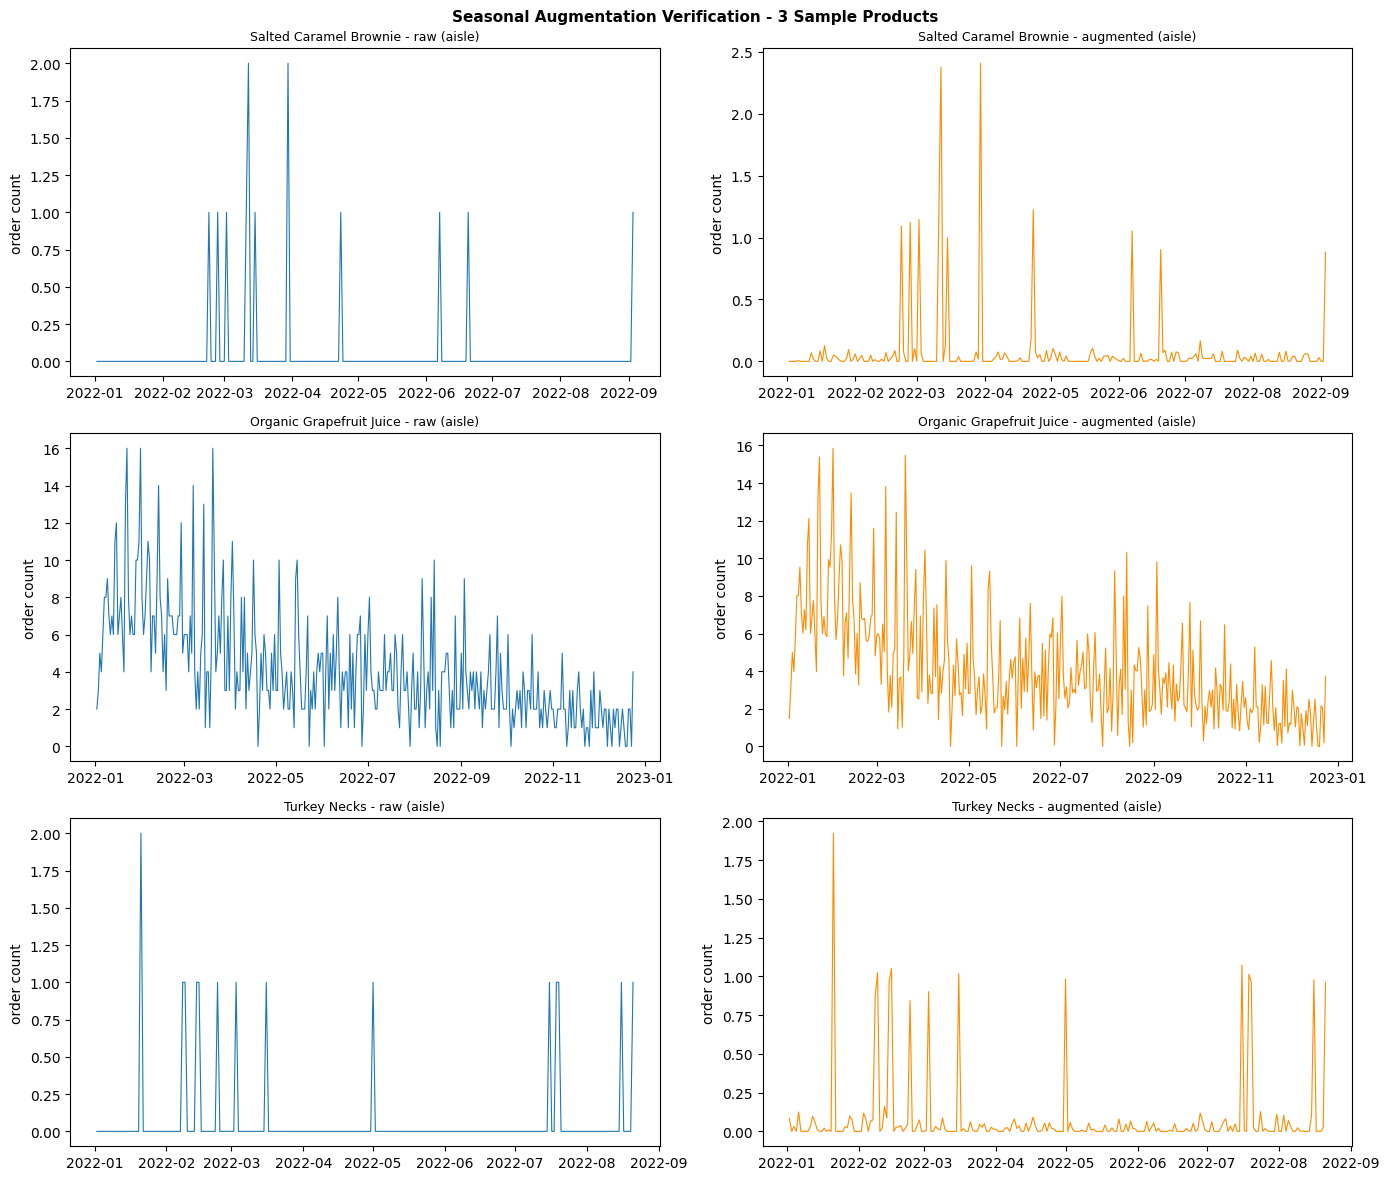


Products qualifying (>= 20 purchases): 254
Products dropped (insufficient purchases)         : 46
Step 7 - Qualifying products: 254

Products normalised: 254


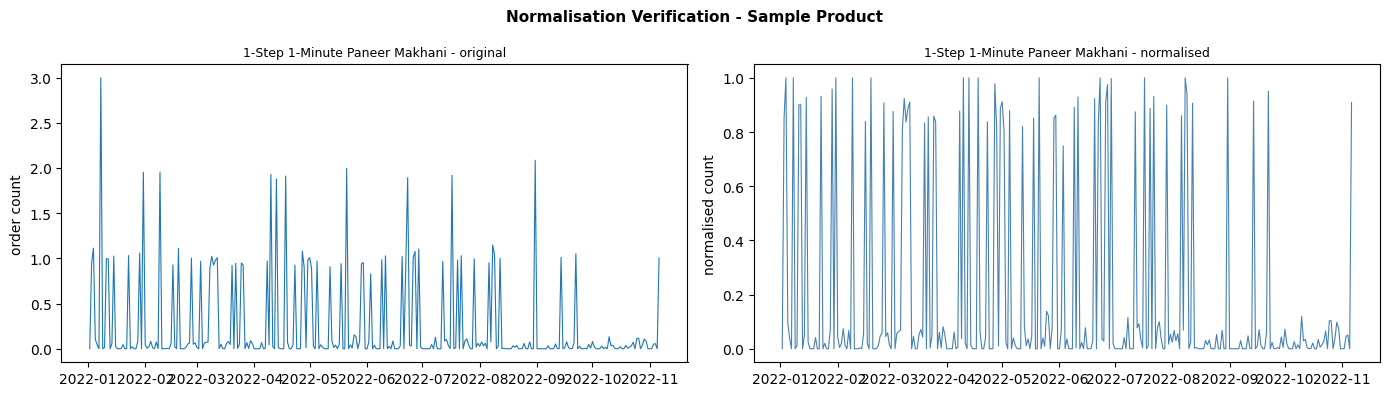


X_train: shape=(42634, 90, 3)
y_train: shape=(42634, 7)
X_val: shape=(6077, 90, 3)
y_val: shape=(6077, 7)
X_test: shape=(12362, 90, 3)
y_test: shape=(12362, 7)
Total windows: 61,073
X_train: shape=(42634, 90, 3)  no NaNs confirmed
y_train: shape=(42634, 7)  no NaNs confirmed
X_val: shape=(6077, 90, 3)  no NaNs confirmed
y_val: shape=(6077, 7)  no NaNs confirmed
X_test: shape=(12362, 90, 3)  no NaNs confirmed
y_test: shape=(12362, 7)  no NaNs confirmed
First training window shape confirmed: (90, 3)
First training window label : [0.68025506 0.28652197 0.4208832  0.67742145 0.12887476 0.2659364
 0.5851687 ]

Test run complete. All temporary files deleted. No checkpoint written. Safe to proceed with the full pipeline.


In [6]:
RUN_TEST = True

if not RUN_TEST:
    print('Test run skipped. Set RUN_TEST = True to execute.')
else:
    import random as _random
    _random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    TEST_TMP = OUTPUT_DIR / 'test_run_tmp'
    TEST_TMP.mkdir(parents=True, exist_ok=True)

    print('=' * 60)
    print('  PREPROCESSING PIPELINE - TEST RUN (300 products)')
    print('=' * 60)
    print()

    # -- Step 1: Filter non-food products --------------------------------------
    t_filtered_products = filter_non_food_products(products, departments)
    print(f'Step 1 - Retained: {len(t_filtered_products):,} food products')
    print()

    # -- Step 2: Reconstruct order dates ---------------------------------------
    t_reconstructed_dates = reconstruct_order_dates(orders, REFERENCE_START_DATE)
    print(f'Step 2 - Date reconstruction complete')
    print()

    # -- Step 3: Sample 300 random products ------------------------------------
    all_food_pids = list(t_filtered_products['product_id'].unique())
    # Draw a random subset to keep the test run fast.
    sampled_pids  = set(_random.sample(all_food_pids, min(300, len(all_food_pids))))
    t_fp_sample   = t_filtered_products[t_filtered_products['product_id'].isin(sampled_pids)]
    t_op_sample   = order_prior[order_prior['product_id'].isin(sampled_pids)]
    print(f'Step 3 - Sampled {len(sampled_pids)} products')
    print()

    # -- Step 4: Aggregate daily counts ----------------------------------------
    t_daily = aggregate_daily_counts(t_op_sample, t_reconstructed_dates, t_fp_sample)
    print(f'Step 4 - Daily counts shape: {t_daily.shape}')
    print()

    # -- Step 5: Build per-product series --------------------------------------
    # Series end at each product's last real order date -- no trailing zeros.
    t_series = build_per_product_series(t_daily)
    print(f'Step 5 - Per-product series built')
    print()

    # -- Step 6: Apply seasonal augmentation + visualisation -------------------
    t_augmented, t_seasonal_cfg = apply_seasonal_augmentation(
        t_series, t_filtered_products, aisles
    )
    print(f'Step 6 - Augmentation applied')

    # Build a name lookup to label the visualisation plots.
    pid_to_name_lookup = dict(zip(products['product_id'], products['product_name']))
    viz_pids = _random.sample(list(t_augmented.keys()), min(3, len(t_augmented)))

    # Plot raw and augmented series side by side for 3 sample products.
    fig, axes = plt.subplots(len(viz_pids), 2, figsize=(14, 4 * len(viz_pids)))
    if len(viz_pids) == 1:
        axes = [axes]
    for row_i, pid in enumerate(viz_pids):
        pname  = pid_to_name_lookup.get(pid, str(pid))
        mlevel = t_seasonal_cfg[pid]['mapping_level']
        ax_raw = axes[row_i][0]
        ax_aug = axes[row_i][1]
        raw_s  = t_series[pid]
        aug_s  = t_augmented[pid]
        ax_raw.plot(raw_s.index, raw_s.values, linewidth=0.8)
        ax_raw.set_title(f'{pname} - raw ({mlevel})', fontsize=9)
        ax_raw.set_ylabel('order count')
        ax_aug.plot(aug_s.index, aug_s.values, linewidth=0.8, color='darkorange')
        ax_aug.set_title(f'{pname} - augmented ({mlevel})', fontsize=9)
        ax_aug.set_ylabel('order count')
    fig.suptitle('Seasonal Augmentation Verification - 3 Sample Products',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    # -- Step 7: Filter qualifying products ------------------------------------
    t_qualifying = filter_qualifying_products(
        t_augmented, min_purchases=MIN_TOTAL_PURCHASES
    )
    print(f'Step 7 - Qualifying products: {len(t_qualifying)}')
    print()

    # -- Step 8: Normalise series + visualisation ------------------------------
    t_normalised, t_scalers = normalise_series(t_qualifying)
    viz_pid  = _random.choice(list(t_normalised.keys()))
    viz_name = pid_to_name_lookup.get(viz_pid, str(viz_pid))
    # Plot original and normalised series for a single product.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(t_qualifying[viz_pid].index, t_qualifying[viz_pid].values, linewidth=0.8)
    ax1.set_title(f'{viz_name} - original', fontsize=9)
    ax1.set_ylabel('order count')
    ax2.plot(t_normalised[viz_pid].index, t_normalised[viz_pid].values,
             linewidth=0.8, color='steelblue')
    ax2.set_title(f'{viz_name} - normalised', fontsize=9)
    ax2.set_ylabel('normalised count')
    fig.suptitle('Normalisation Verification - Sample Product',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    # -- Step 9: Build sliding windows -----------------------------------------
    t_X_train, t_y_train, t_X_val, t_y_val, t_X_test, t_y_test = build_sliding_windows(
        t_normalised, INPUT_WINDOW, OUTPUT_HORIZON, STRIDE
    )
    # Assert that no NaN values have been introduced anywhere in the window arrays.
    for name, arr in [('X_train', t_X_train), ('y_train', t_y_train),
                      ('X_val',   t_X_val),   ('y_val',   t_y_val),
                      ('X_test',  t_X_test),  ('y_test',  t_y_test)]:
        assert not np.isnan(arr).any(), f'NaN values found in {name}'
        print(f'{name}: shape={arr.shape}  no NaNs confirmed')
    # Confirm array dimensions match configured constants.
    assert t_X_train.shape[1] == INPUT_WINDOW, 'Input window size mismatch'
    assert t_X_train.shape[2] == N_FEATURES,   'Feature count mismatch'
    assert t_y_train.shape[1] == OUTPUT_HORIZON, 'Output horizon mismatch'
    print(f'First training window shape confirmed: {t_X_train[0].shape}')
    print(f'First training window label : {t_y_train[0]}')
    print()

    # -- Step 10: Write test artefacts, verify, delete -------------------------
    # Save all arrays to disk and reload them to confirm the I/O round-trip works.
    for name, arr in [('X_train', t_X_train), ('y_train', t_y_train),
                      ('X_val',   t_X_val),   ('y_val',   t_y_val),
                      ('X_test',  t_X_test),  ('y_test',  t_y_test)]:
        np.save(TEST_TMP / f'{name}.npy', arr)
    joblib.dump(t_scalers, TEST_TMP / 'scalers_test.joblib')

    for name, arr in [('X_train', t_X_train), ('y_train', t_y_train),
                      ('X_val',   t_X_val),   ('y_val',   t_y_val),
                      ('X_test',  t_X_test),  ('y_test',  t_y_test)]:
        loaded = np.load(TEST_TMP / f'{name}.npy')
        assert loaded.shape == arr.shape, f'Shape mismatch for {name}'
    loaded_scalers = joblib.load(TEST_TMP / 'scalers_test.joblib')
    assert len(loaded_scalers) == len(t_scalers)

    # Delete the temporary directory; no permanent files should remain.
    import shutil as _shutil
    _shutil.rmtree(TEST_TMP)
    print('Test run complete. All temporary files deleted. '
          'No checkpoint written. Safe to proceed with the full pipeline.')

## Section 6  -  Filter Non-Food Products

Removes products in non-food departments before building time series. This section shares a checkpoint with Section 7.

In [7]:
if reached_stage(CURRENT_STAGE, 'dates_reconstructed'):
    print(f'Section 6 skipped: already past dates_reconstructed (stage={CURRENT_STAGE}).')
    if 'filtered_products' not in dir():
        # Reload from disk if the variable is not already in memory from a previous cell.
        filtered_products = pd.read_parquet(OUTPUT_DIR / 'filtered_products_1b.parquet')
        print(f'Loaded filtered_products: {len(filtered_products):,} products')
else:
    filtered_products = filter_non_food_products(products, departments)
    filtered_products.to_parquet(OUTPUT_DIR / 'filtered_products_1b.parquet', index=False)
    print('Saved: filtered_products_1b.parquet')

Dropped departments:
  personal care: 6,563 products
  household: 3,085 products
  missing: 1,258 products
  babies: 1,081 products
  alcohol: 1,054 products
  pets: 972 products
  other: 548 products
Products retained: 35,127  (dropped: 14,561)
Saved: filtered_products_1b.parquet


## Section 7  -  Reconstruct Order Dates

Reconstructs a calendar date for every order by anchoring each user's first order to `REFERENCE_START_DATE` and cumulatively adding inter-order gaps.

In [8]:
if reached_stage(CURRENT_STAGE, 'dates_reconstructed'):
    print(f'Section 7 skipped: already past dates_reconstructed (stage={CURRENT_STAGE}).')
    if 'reconstructed_dates' not in dir():
        # Reload from disk if the variable is not already in memory.
        reconstructed_dates = pd.read_parquet(OUTPUT_DIR / 'reconstructed_dates.parquet')
        print(f'Loaded reconstructed_dates: {len(reconstructed_dates):,} orders')
else:
    reconstructed_dates = reconstruct_order_dates(orders, REFERENCE_START_DATE)
    reconstructed_dates.to_parquet(OUTPUT_DIR / 'reconstructed_dates.parquet', index=False)
    print('Saved: reconstructed_dates.parquet')
    # Advance the checkpoint: both Section 6 and Section 7 are now complete.
    save_checkpoint('dates_reconstructed')
    CURRENT_STAGE = 'dates_reconstructed'

Total orders processed: 3,421,083
Date range: 2022-01-01 to 2023-01-01
Saved: reconstructed_dates.parquet
Checkpoint saved: stage=dates_reconstructed  timestamp=2026-04-12T11:40:38.411314


## Section 8  -  Aggregate Daily Counts and Build Per-Product Series

Aggregates order-level data to daily counts per product, then builds a continuous daily time series for each product with missing days filled with zero. Each product's series starts on its own first order date.

In [9]:
if reached_stage(CURRENT_STAGE, 'counts_aggregated'):
    print(f'Section 8 skipped: counts already aggregated (stage={CURRENT_STAGE}).')
else:
    if 'reconstructed_dates' not in dir():
        reconstructed_dates = pd.read_parquet(OUTPUT_DIR / 'reconstructed_dates.parquet')
    if 'filtered_products' not in dir():
        filtered_products = pd.read_parquet(OUTPUT_DIR / 'filtered_products_1b.parquet')

    # Aggregate line-item data to daily counts per product.
    daily_counts_raw    = aggregate_daily_counts(
        order_prior, reconstructed_dates, filtered_products
    )
    # Build gapless per-product time series.
    product_series_dict = build_per_product_series(daily_counts_raw)

    # Convert dict of Series to long-format dataframe before saving.
    # Each series ends at the product's own last real order date.
    frames = []
    for pid, series in product_series_dict.items():
        frames.append(pd.DataFrame({
            'product_id' : pid,
            'date'       : series.index,
            'order_count': series.values,
        }))
    daily_long = pd.concat(frames, ignore_index=True)
    daily_long.to_parquet(OUTPUT_DIR / 'daily_counts_raw.parquet', index=False)
    print('Saved: daily_counts_raw.parquet')

    save_checkpoint('counts_aggregated')
    CURRENT_STAGE = 'counts_aggregated'

Unique products in daily counts: 35,121
Date range: 2022-01-01 to 2023-01-01
Products processed : 35,121
Series length  min=0  max=365  mean=310.6  median=343.0
Note: each series ends at the product's own last real order date. No trailing zeros are added.
Saved: daily_counts_raw.parquet
Checkpoint saved: stage=counts_aggregated  timestamp=2026-04-12T11:41:58.514436


## Section 9  -  Apply Seasonal Augmentation

Applies a sinusoidal seasonal multiplier to each product's daily order counts, with amplitude and peak day chosen by product keyword or aisle. Gaussian noise is added to prevent overfitting to the synthetic curve.

In [10]:
if reached_stage(CURRENT_STAGE, 'seasonal_augmented'):
    print(f'Section 9 skipped: seasonal augmentation already applied (stage={CURRENT_STAGE}).')
else:
    if 'filtered_products' not in dir():
        filtered_products = pd.read_parquet(OUTPUT_DIR / 'filtered_products_1b.parquet')
    if 'aisles' not in dir():
        aisles = pd.read_csv(RAW_DIR / 'aisles.csv', low_memory=False)
    if 'product_series_dict' not in dir():
        # Rebuild product_series_dict from the saved parquet if not in memory.
        daily_raw = pd.read_parquet(OUTPUT_DIR / 'daily_counts_raw.parquet')
        daily_raw['date'] = pd.to_datetime(daily_raw['date'])
        product_series_dict = {}
        for pid, grp in daily_raw.groupby('product_id'):
            product_series_dict[pid] = grp.set_index('date').sort_index()['order_count']
        print(f'Rebuilt product_series_dict: {len(product_series_dict):,} products')

    augmented_series, seasonal_config = apply_seasonal_augmentation(
        product_series_dict, filtered_products, aisles
    )

    # Save augmented series as long-format parquet.
    aug_frames = []
    for pid, series in augmented_series.items():
        aug_frames.append(pd.DataFrame({
            'product_id' : pid,
            'date'       : series.index,
            'order_count': series.values,
        }))
    aug_long = pd.concat(aug_frames, ignore_index=True)
    aug_long.to_parquet(OUTPUT_DIR / 'daily_counts_augmented.parquet', index=False)
    print('Saved: daily_counts_augmented.parquet')

    # JSON requires string keys; convert integer product IDs before serialising.
    seasonal_config_str = {str(pid): cfg for pid, cfg in seasonal_config.items()}
    with open(OUTPUT_DIR / 'seasonal_config.json', 'w', encoding='utf-8') as fh:
        json.dump(seasonal_config_str, fh, indent=2)
    print('Saved: seasonal_config.json')

    save_checkpoint('seasonal_augmented')
    CURRENT_STAGE = 'seasonal_augmented'

Products using keyword overrides : 5,255
Products using aisle-level profile: 29,866
Saved: daily_counts_augmented.parquet
Saved: seasonal_config.json
Checkpoint saved: stage=seasonal_augmented  timestamp=2026-04-12T11:43:10.544702


## Section 10  -  Filter Qualifying Products and Normalise

Removes products with too few total purchases, then normalises each qualifying product's series to [0, 1] using a MinMaxScaler fitted on the training portion only.

In [11]:
if reached_stage(CURRENT_STAGE, 'normalised'):
    print(f'Section 10 skipped: normalisation already complete (stage={CURRENT_STAGE}).')
else:
    if 'augmented_series' not in dir():
        # Rebuild augmented_series from disk if not already in memory.
        aug_raw = pd.read_parquet(OUTPUT_DIR / 'daily_counts_augmented.parquet')
        aug_raw['date'] = pd.to_datetime(aug_raw['date'])
        augmented_series = {}
        for pid, grp in aug_raw.groupby('product_id'):
            augmented_series[pid] = grp.set_index('date').sort_index()['order_count']
        print(f'Rebuilt augmented_series: {len(augmented_series):,} products')

    # Remove products that do not have enough purchase history.
    qualifying_series = filter_qualifying_products(
        augmented_series, MIN_TOTAL_PURCHASES
    )
    # Normalise each product's series independently; scalers are saved for inverse transform.
    normalised_series, scalers = normalise_series(qualifying_series)

    joblib.dump(scalers, OUTPUT_DIR / 'scalers.joblib')
    print('Saved: scalers.joblib')

    # Save the list of qualifying product IDs for use in the training notebook.
    qualifying_pids = [int(pid) for pid in qualifying_series.keys()]
    with open(OUTPUT_DIR / 'qualifying_products.json', 'w', encoding='utf-8') as fh:
        json.dump(qualifying_pids, fh)
    print('Saved: qualifying_products.json')

    save_checkpoint('normalised')
    CURRENT_STAGE = 'normalised'

Products qualifying (>= 20 purchases): 28,552
Products dropped (insufficient purchases)         : 6,569
Products normalised: 28,552
Saved: scalers.joblib
Saved: qualifying_products.json
Checkpoint saved: stage=normalised  timestamp=2026-04-12T11:44:33.721627


## Section 11  -  Build Sliding Windows

Extracts sliding windows from each product's normalised series and splits them into train, validation, and test sets by temporal position. Training windows are shuffled before saving.

In [12]:
if reached_stage(CURRENT_STAGE, 'windows_built'):
    print(f'Section 11 skipped: windows already built (stage={CURRENT_STAGE}).')
else:
    if 'normalised_series' not in dir():
        with open(OUTPUT_DIR / 'qualifying_products.json') as fh:
            _qpids = json.load(fh)
        scalers = joblib.load(OUTPUT_DIR / 'scalers.joblib')

        # Rebuild augmented series for qualifying products only.
        aug_raw = pd.read_parquet(OUTPUT_DIR / 'daily_counts_augmented.parquet')
        aug_raw['date'] = pd.to_datetime(aug_raw['date'])
        aug_dict = {}
        for pid, grp in aug_raw.groupby('product_id'):
            aug_dict[pid] = grp.set_index('date').sort_index()['order_count']
        qualifying_series = {pid: aug_dict[pid] for pid in _qpids if pid in aug_dict}

        # Normalise using the same logic as Section 10.
        normalised_series, _ = normalise_series(qualifying_series)
        print(f'Rebuilt normalised_series: {len(normalised_series):,} products')

    # Build windows from normalised series, split into train/val/test.
    X_train, y_train, X_val, y_val, X_test, y_test = build_sliding_windows(
        normalised_series, INPUT_WINDOW, OUTPUT_HORIZON, STRIDE
    )

    # Save each array to disk.
    np.save(OUTPUT_DIR / 'X_train.npy', X_train)
    np.save(OUTPUT_DIR / 'y_train.npy', y_train)
    np.save(OUTPUT_DIR / 'X_val.npy',   X_val)
    np.save(OUTPUT_DIR / 'y_val.npy',   y_val)
    np.save(OUTPUT_DIR / 'X_test.npy',  X_test)
    np.save(OUTPUT_DIR / 'y_test.npy',  y_test)
    print('Saved: X_train.npy, y_train.npy, X_val.npy, y_val.npy, X_test.npy, y_test.npy')

    # Save a summary of window counts and shapes for reference in the training notebook.
    window_summary = {
        'n_train_windows'      : int(len(X_train)),
        'n_val_windows'        : int(len(X_val)),
        'n_test_windows'       : int(len(X_test)),
        'input_window'         : INPUT_WINDOW,
        'output_horizon'       : OUTPUT_HORIZON,
        'stride'               : STRIDE,
        'n_features'           : N_FEATURES,
        'n_qualifying_products': len(normalised_series),
        'total_windows'        : int(len(X_train) + len(X_val) + len(X_test)),
    }
    with open(OUTPUT_DIR / 'window_summary.json', 'w', encoding='utf-8') as fh:
        json.dump(window_summary, fh, indent=2)
    print('Saved: window_summary.json')

    save_checkpoint('windows_built')
    CURRENT_STAGE = 'windows_built'
    # Pipeline is now fully complete.
    save_checkpoint('complete')
    CURRENT_STAGE = 'complete'

X_train: shape=(4764878, 90, 3)
y_train: shape=(4764878, 7)
X_val: shape=(679385, 90, 3)
y_val: shape=(679385, 7)
X_test: shape=(1381664, 90, 3)
y_test: shape=(1381664, 7)
Total windows: 6,825,927
Saved: X_train.npy, y_train.npy, X_val.npy, y_val.npy, X_test.npy, y_test.npy
Saved: window_summary.json
Checkpoint saved: stage=windows_built  timestamp=2026-04-12T11:46:07.117178
Checkpoint saved: stage=complete  timestamp=2026-04-12T11:46:07.136077


## Section 12  -  Verification and Summary

Checks that all expected output files are present and prints key properties of each.

In [13]:
# List every output file the pipeline is expected to produce.
manifest = [
    'filtered_products_1b.parquet',
    'reconstructed_dates.parquet',
    'daily_counts_raw.parquet',
    'daily_counts_augmented.parquet',
    'scalers.joblib',
    'qualifying_products.json',
    'seasonal_config.json',
    'window_summary.json',
    'X_train.npy',
    'y_train.npy',
    'X_val.npy',
    'y_val.npy',
    'X_test.npy',
    'y_test.npy',
    'preprocessing_checkpoint.json',
]

print('=' * 60)
print('  OUTPUT FILE MANIFEST')
print('=' * 60)
all_present = True
for fname in manifest:
    fpath  = OUTPUT_DIR / fname
    status = 'OK' if fpath.exists() else 'MISSING'
    if status == 'MISSING':
        all_present = False
    print(f'  {status:<8}  {fname}')
print()

# For each present file, load it and print a brief summary.
print('File details:')
for fname, loader, label in [
    ('filtered_products_1b.parquet',   lambda p: pd.read_parquet(p),      'shape'),
    ('reconstructed_dates.parquet',    lambda p: pd.read_parquet(p),      'shape'),
    ('daily_counts_raw.parquet',       lambda p: pd.read_parquet(p),      'shape'),
    ('daily_counts_augmented.parquet', lambda p: pd.read_parquet(p),      'shape'),
    ('qualifying_products.json',       lambda p: json.load(open(p)),      'len'),
    ('seasonal_config.json',           lambda p: json.load(open(p)),      'len'),
    ('window_summary.json',            lambda p: json.load(open(p)),      'content'),
    # mmap_mode='r' reads only the array header to retrieve the shape,
    # avoiding loading the full array (potentially hundreds of MB) into memory.
    ('X_train.npy', lambda p: np.load(p, mmap_mode='r'), 'shape'),
    ('y_train.npy', lambda p: np.load(p, mmap_mode='r'), 'shape'),
    ('X_val.npy',   lambda p: np.load(p, mmap_mode='r'), 'shape'),
    ('y_val.npy',   lambda p: np.load(p, mmap_mode='r'), 'shape'),
    ('X_test.npy',  lambda p: np.load(p, mmap_mode='r'), 'shape'),
    ('y_test.npy',  lambda p: np.load(p, mmap_mode='r'), 'shape'),
]:
    fpath = OUTPUT_DIR / fname
    if not fpath.exists():
        continue
    obj = loader(fpath)
    if label == 'shape':
        info = obj.shape
    elif label == 'len':
        info = f'{len(obj):,} entries'
    else:
        info = str(obj)
    print(f'  {fname:<42}  {info}')

print()
if all_present:
    print('Task 1B preprocessing complete. All artefacts verified.')
else:
    print('WARNING: some output files are missing. Re-run the relevant sections.')

  OUTPUT FILE MANIFEST
  OK        filtered_products_1b.parquet
  OK        reconstructed_dates.parquet
  OK        daily_counts_raw.parquet
  OK        daily_counts_augmented.parquet
  OK        scalers.joblib
  OK        qualifying_products.json
  OK        seasonal_config.json
  OK        window_summary.json
  OK        X_train.npy
  OK        y_train.npy
  OK        X_val.npy
  OK        y_val.npy
  OK        X_test.npy
  OK        y_test.npy
  OK        preprocessing_checkpoint.json

File details:
  filtered_products_1b.parquet                (35127, 5)
  reconstructed_dates.parquet                 (3421083, 3)
  daily_counts_raw.parquet                    (10907296, 3)
  daily_counts_augmented.parquet              (10907296, 3)
  qualifying_products.json                    28,552 entries
  seasonal_config.json                        35,121 entries
  window_summary.json                         {'n_train_windows': 4764878, 'n_val_windows': 679385, 'n_test_windows': 1381664, 'input_